# Composizione e riconoscimento di un numero telefonico

Applichiamo ora le conoscenze acquisite a un semplice problema: la codifica e decodifica di un numero di telefono.

Analogamente la stessa procedura può essere utilizzata per riconoscere una nota suonata da uno strumento musicale.

Quando richiesto, si utilizzi il padlet presente a questo indirizzo per fornire feedback sull'esercitazione:
https://padlet.com/polito/ead-dtmf-november-17-2025-brv5nyex80xomr04

**Importante**: si è qui per imparare, non per "finire" l'esercizio, si cerchino pure informazioni _puntuali_ su Internet e nel materiale presentato a lezione, ma non si cerchi l'esercizio completo già svolto o lo si faccia svolgere da capo a fine a ChatGPT o al vicino di banco! Grazie.

In [1]:
# INSTALLAZIONE E IMPORT DEI PACCHETTI

!pip install librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa

In [2]:
def dft(x, Fs, N=None):
  L = len(x)
  N = L if N is None else N
  X = np.fft.rfft(x, N)
  X_ = np.abs(X) / (L/2)
  freq = np.fft.rfftfreq(N, d=1./Fs)
  # X_ = X_[:N//2+1]
  # freq = freq[:N//2+1]
  # X_dBFS = X_ # 20*np.log10(X_)
  return X_, freq

def RMS(x):
  return np.sqrt(np.mean(x**2))

def dBFS(x):
  return 20*np.log10(RMS(x))


# plot frequency spectrum
def plot_vs_freq(X, f, Fs, type="linear", xlim=None, ylim=None, fig=None, zp=False, fmt="-"):

  fig, ax = plt.subplots(figsize=(6,3)) if fig is None else fig
  xlim = [np.min(f), np.max(f)] if xlim is None else xlim

  if type == "linear":
    ax.set_ylabel('Magnitude')
    ylim = [0, 1.2] if ylim is None else ylim
    X = X
  elif type == "log":
    ax.set_ylabel('Power (dBFS)')
    ylim = [-60, +6] if ylim is None else ylim
    X = 10*np.log10(X**2)

  ax.plot(f, X, fmt)
  ax.set_xlabel('Frequency (Hz)')

  ax.set_xlim(xlim)
  ax.set_ylim(ylim)
  plt.grid(visible=True);
  plt.tight_layout()

# plot_vs_freq(x, Fs, N)
# plot_vs_freq(x, Fs, N, xlim=[2, 5], ylim=[-10, 3])

def gen_cos(dur=1, Fs=100, amp=1, freq=2, phase=0):
    num_samples = int(Fs * dur)
    t = np.arange(num_samples) / Fs
    x = amp * np.cos( (2*np.pi*freq*t) + phase)
    return x, t

def normalize(x):
  return x / np.max(np.abs(x))

## Segnalazione DTMF (Dual-Tone Multi-Frequency)

Quando il telefono compone un numero, è possibile ascoltare una sequenza di suoni. Ciascun suono codifica una cifra diversa da comporre. I suoni sono segnali a due toni definiti come:

$$
x(t) = \cos(2\pi f_1 t) + \cos(2\pi f_2 t),
$$

dove $f_1$ e $f_2$ dipendono dalla cifra da comporre. Le frequenze sono codificate secondo la seguente tabella:

| Frequenza Colonna (Hz) | 1209 Hz | 1336 Hz | 1477 Hz | 1633 Hz |
|-------------------------|---------|---------|---------|---------|
| **Frequenza Riga (Hz)** |         |         |         |         |
| **697 Hz**             |    1    |    2    |    3    |    A    |
| **770 Hz**             |    4    |    5    |    6    |    B    |
| **852 Hz**             |    7    |    8    |    9    |    C    |
| **941 Hz**             |    *    |    0    |    #    |    D    |

Ad esempio, componendo la cifra 5, il segnale corrispondente ha la forma:

$$
x_5(t) = \cos(2\pi f_1 t) + \cos(2\pi f_2 t),
$$

con $f_1 = 770 \, \text{Hz}$ e $f_2 = 1336 \, \text{Hz}$.



In [3]:
F1 = np.array([697, 770, 852, 941])
F2 = np.array([1209, 1336, 1477, 1633])
tones = {
    '1': (0,0), '2': (0,1), '3': (0,2), 'A': (0,3),
    '4': (1,0), '5': (1,1), '6': (1,2), 'B': (1,3),
    '7': (2,0), '8': (2,1), '9': (2,2), 'C': (2,3),
    '0': (3,1), '*': (3,0), '#': (3,2), 'D': (3,3)
}

for number, inds in sorted(tones.items()):
    print ("%s: %dHz %dHz (delta-F: %dHz)" % (number, F1[inds[0]], F2[inds[1]], (F2[inds[1]]-F1[inds[0]])))

#: 941Hz 1477Hz (delta-F: 536Hz)
*: 941Hz 1209Hz (delta-F: 268Hz)
0: 941Hz 1336Hz (delta-F: 395Hz)
1: 697Hz 1209Hz (delta-F: 512Hz)
2: 697Hz 1336Hz (delta-F: 639Hz)
3: 697Hz 1477Hz (delta-F: 780Hz)
4: 770Hz 1209Hz (delta-F: 439Hz)
5: 770Hz 1336Hz (delta-F: 566Hz)
6: 770Hz 1477Hz (delta-F: 707Hz)
7: 852Hz 1209Hz (delta-F: 357Hz)
8: 852Hz 1336Hz (delta-F: 484Hz)
9: 852Hz 1477Hz (delta-F: 625Hz)
A: 697Hz 1633Hz (delta-F: 936Hz)
B: 770Hz 1633Hz (delta-F: 863Hz)
C: 852Hz 1633Hz (delta-F: 781Hz)
D: 941Hz 1633Hz (delta-F: 692Hz)


## Attività 1: generazione del dual-tone

Si scriva una funzione che genera il segnale per una determinata cifra con una certa durata e lo si ascolti (si usi Fs = 8 kHz).

Con l'esercitazione è fornito un file di esempio: dtmf-example.wav


In [ ]:
Fs = 8000

## Attività 2: Analisi in frequenza dei dual-tone

Il compito ora è scrivere un programma che possa decodificare la cifra corrispondente ad una sequenza sonora.

Si componga il dual-tone corrispondente alla cifra `*`, poiché presenta la minima distanza tra le due frequenze contenute, rendendola la cifra più impegnativa da analizzare.

Se ne rappresenti il modulo dello spettro e lo si sovrapponga alla figura di seguito che riporta la posizione dei toni possibili nel segnale.

Si sottometta il grafico così realizzato sul padlet raggiungibile all'indirizzo specificato all'inizio dell'esercitazione.

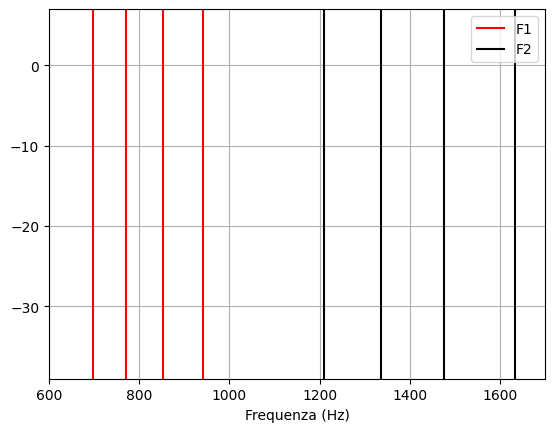

In [4]:

for f in F1:
    line1 = plt.axvline(f, color='r')
for f in F2:
    line2 = plt.axvline(f, color='k')
plt.xlabel('Frequenza (Hz)')
plt.legend([line1, line2], [ 'F1', 'F2'])

plt.xlim((600, 1700))
plt.grid(True)

ylim = plt.ylim()
plt.ylim((ylim[1]-40, ylim[1]+6))
plt.show()

## Attività 3: Riconoscimento della cifra a partire dal dual-tone

Ora scriviamo una funzione che esegua la stima di un tono, anzi due, a partire dallo spettro di un segnale:

1. la funzione riceva una forma d'onda contenente il "dual-tone" corrispondente ad una cifra
2. Si trovino i *bin* (o frequenze campionate) dello spettro a cui corrispondono le frequenze in F1 ed F2
3. Si cerchi in quei "punti" quali frequenze sono presenti
  - per "presenza" si intende che abbiano un valore significativamente diverso da 0 (o -inf)
  - tra queste dovrebbero essere presenti due frequenze più "forti" delle altre, una appartenente ad F1 ed una ad F2
4. In base alle frequenze individuate si decodifichi la cifra riconosciuta


Si faccia attenzione alla scelta della durata del dual-tone e si confronti la propria scelta con quella di altri compagni/gruppi.


## Analisi attività 3

Si forniscano feedback utilizzando il padlet raggiungibile all'indirizzo specificato all'inizio dell'esercitazione.

- Il testo dell'attività è stato scritto in modo chiaro, comprensibile?
- Quali dubbi sono sorti su come svolgere l'attività?
- Quali informazioni su come fare determinati passaggi sono state più difficili da reperire? Sia da Internet sia dal materiale delle lezioni.
- Quanta parte dell'attività richiesta si è riusciti a svolgere nel tempo assegnato?
- Quali sono le maggiori difficoltà che sono state riscontrate?
- Quali consigli si suggeriscono per migliorare la preparazione e lo svolgimento dell'attività quando verrà riproposta agli studenti del prossimo anno?







## Attività 4 e 5: approfondimenti






### Durata del segnale

Quale durata del dual-tone è stata scelta?

Si provi a ridurre la durata del segnale
- che problemi insorgono nel riconoscimento?
- i problemi si verificano su tutte le cifre o solo su alcune?
- quale stratagemma può essere utilizzato per migliorare il riconoscimento? fino a "quando" funziona?

### Rumore "ambientale"

E' possibile che durante la propagazione su cavo o nell'ambiente, il segnale venga sporcato da rumore che può rendere meno efficace la procedura di riconoscimento.

Si provi ad aggiungere del rumore gaussiano bianco al dual-tone, quale è il livello di rumore che inizia a creare disturbi di riconoscimento?


In [ ]:
def addNoise(signal, level):
  return signal + level*np.random.randn(len(signal))

